<a href="https://colab.research.google.com/github/TegarAdh/Machine-Learning/blob/main/Garbage_Classification_CNN--ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning - Image Classification with CNN ResNet50 Transfer Learning**
---

Dataset : [Garbage Image Dataset](https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset)

Auth    : [Tegar Adhi Nugraha Christ During](https://github.com/TegarAdh)


## ***Download Dataset***

In [1]:
#!kaggle datasets download -d farzadnekouei/trash-type-image-dataset
#!unzip -q trash-type-image-dataset.zip -d dataset


## **Import Library**

In [2]:
import os
import shutil
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input


## **Konfigurasi Hyperparameter**

> ⚠️ **FIX #1**: Variabel `IMG_SIZE` dan `BATCH_SIZE` sebelumnya tidak didefinisikan, menyebabkan `NameError` saat membuat generator.

In [3]:
# =============================================
# KONFIGURASI UTAMA — definisikan di sini
# =============================================
IMG_SIZE    = 224      # ukuran input ResNet50
BATCH_SIZE  = 32
EPOCHS_INIT = 20       # fase 1: feature extraction
EPOCHS_FT   = 15       # fase 2: fine-tuning
RANDOM_SEED = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## **Load Dataset**

In [4]:
DATASET_DIR = '/content/dataset/TrashType_Image_Dataset'

classes = sorted(os.listdir(DATASET_DIR))
print('Classes:', classes)


Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
class_counts = []

for cls in classes:
    path = os.path.join(DATASET_DIR, cls)
    class_counts.append(len(os.listdir(path)))

df = pd.DataFrame({'Class': classes, 'Count': class_counts})
df


,Class,Count
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


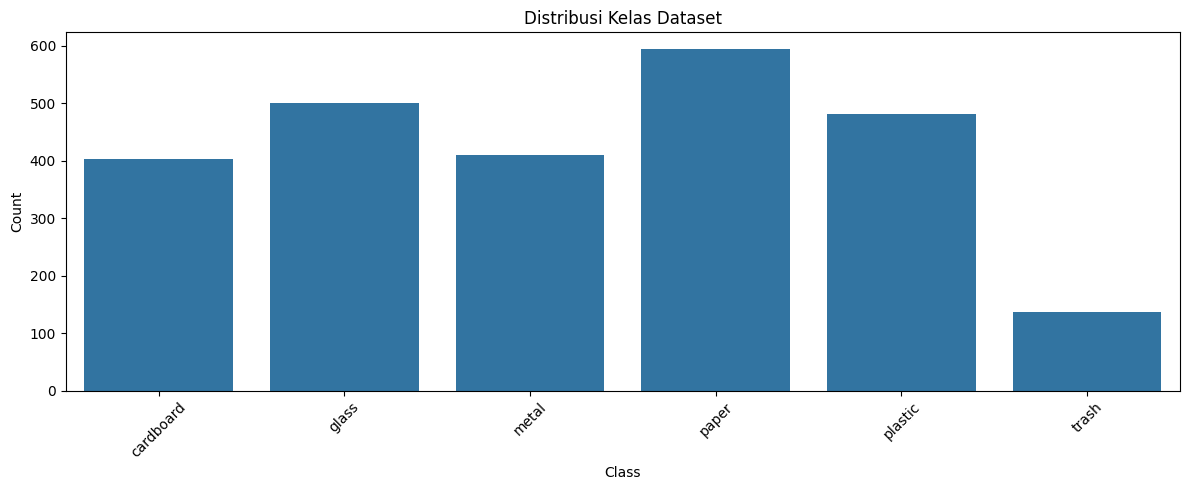

In [6]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='Class', y='Count')
plt.xticks(rotation=45)
plt.title('Distribusi Kelas Dataset')
plt.tight_layout()
plt.show()


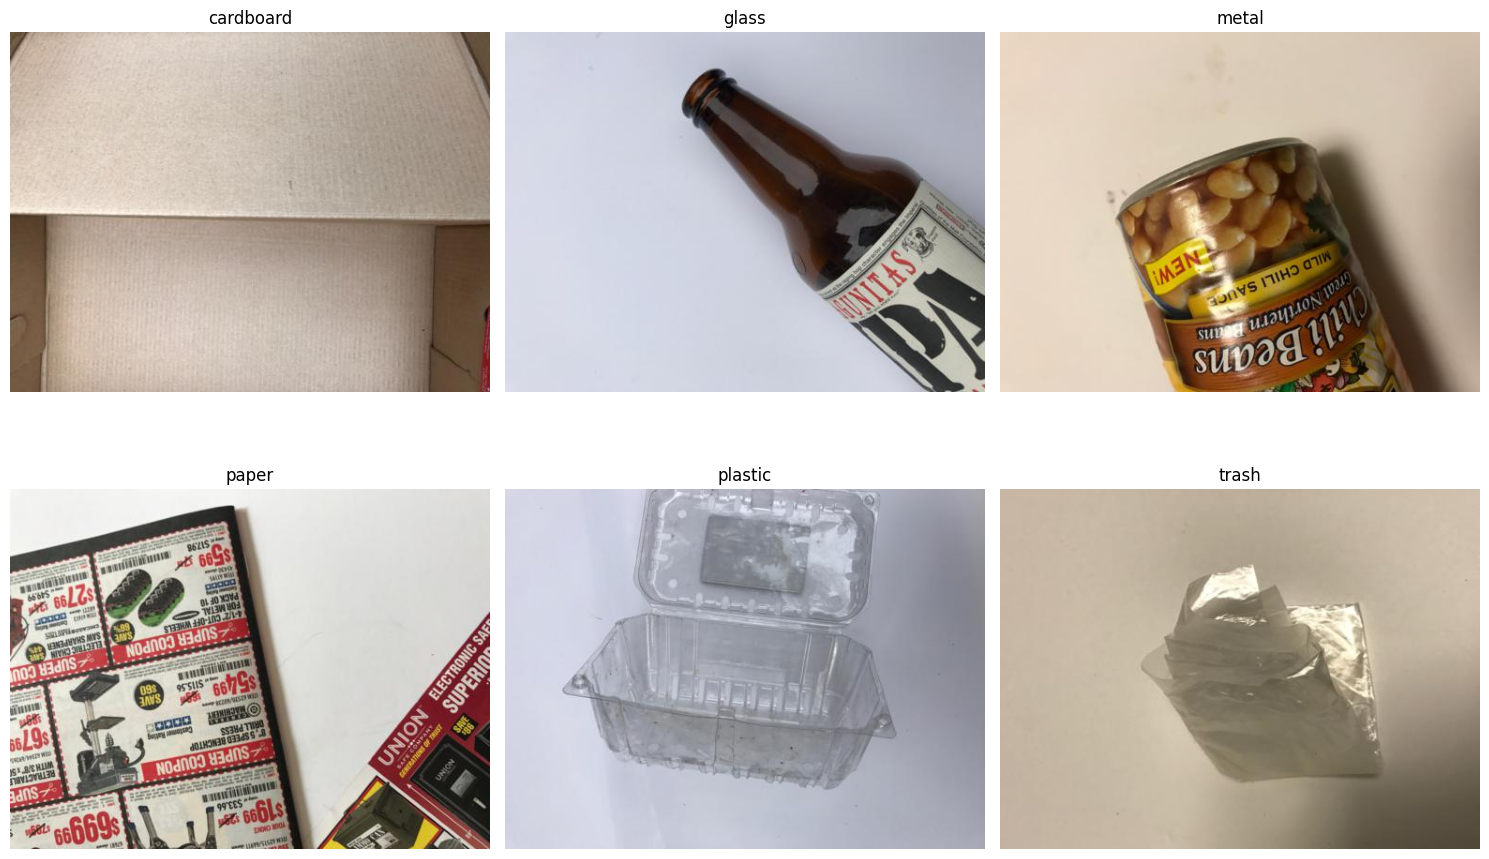

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    folder = os.path.join(DATASET_DIR, cls)
    img_name = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_name))
    axes[idx].imshow(img)
    axes[idx].set_title(cls)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


## **Split Dataset**

In [8]:
SOURCE_DIR = '/content/dataset/TrashType_Image_Dataset'
OUTPUT_DIR = '/content/trash_split'

TRAIN_DIR = os.path.join(OUTPUT_DIR, 'train')
VAL_DIR   = os.path.join(OUTPUT_DIR, 'val')
TEST_DIR  = os.path.join(OUTPUT_DIR, 'test')

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Gunakan classes yang sudah didefinisikan sebelumnya
# TIDAK perlu sorted(os.listdir()) lagi — sudah ada di atas
print('Classes:', classes)


Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [9]:
for cls in classes:
    files = os.listdir(os.path.join(SOURCE_DIR, cls))

    train_files, temp_files = train_test_split(
        files, test_size=0.3, random_state=RANDOM_SEED
    )

    val_files, test_files = train_test_split(
        temp_files, test_size=0.5, random_state=RANDOM_SEED
    )

    for split_name, split_files in zip(
        ['train', 'val', 'test'],
        [train_files, val_files, test_files]
    ):
        split_dir = os.path.join(OUTPUT_DIR, split_name, cls)
        os.makedirs(split_dir, exist_ok=True)
        for file in split_files:
            shutil.copy(
                os.path.join(SOURCE_DIR, cls, file),
                os.path.join(split_dir, file)
            )

print('Dataset split selesai!')


Dataset split selesai!


## **Data Processing**

> ⚠️ **FIX #2**: `class_weight_dict` sekarang dibangun SETELAH generator dibuat,
> menggunakan `train_generator.class_indices` agar urutan indeks kelas konsisten.
> Sebelumnya, urutan manual bisa berbeda dari urutan generator → class weight salah kelas.


In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # bukan rescale
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [11]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # PENTING: jangan di-shuffle untuk evaluasi
)

print('Class indices (generator):', train_generator.class_indices)


Found 1766 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.
Class indices (generator): {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [12]:
# =============================================
# FIX #2: Bangun class_weight dari generator,
# bukan dari os.listdir() manual
# =============================================
train_labels = train_generator.classes  # array int sesuai class_indices

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(weights))
print('Class weight dict:', class_weight_dict)


Class weight dict: {0: np.float64(1.0437352245862883), 1: np.float64(0.840952380952381), 2: np.float64(1.0255516840882695), 3: np.float64(0.7092369477911646), 4: np.float64(0.8733926805143423), 5: np.float64(3.0982456140350876)}


## **ResNet50 Transfer Learning**

In [13]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Fase 1: Freeze semua layer base model
for layer in base_model.layers:
    layer.trainable = False

print(f'Base model layers: {len(base_model.layers)}')
print(f'Trainable layers (fase 1): {sum(1 for l in base_model.layers if l.trainable)}')


Base model layers: 175
Trainable layers (fase 1): 0


In [14]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,777,862 (94.52 MB)

 Trainable params: 1,186,054 (4.52 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        verbose=1
    ),
    ModelCheckpoint(
        'best_resnet50.keras',
        save_best_only=True,
        verbose=1
    )
]


## **Training — Fase 1: Feature Extraction**

In [17]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_INIT,
    callbacks=callbacks,
    class_weight=class_weight_dict
)


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.2734 - loss: 2.1360
Epoch 1: val_loss improved from None to 0.99265, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 56s 736ms/step - accuracy: 0.3539 - loss: 1.8383 - val_accuracy: 0.6402 - val_loss: 0.9927 - learning_rate: 1.0000e-04
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.5512 - loss: 1.2315
Epoch 2: val_loss improved from 0.99265 to 0.75657, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 462ms/step - accuracy: 0.5685 - loss: 1.1671 - val_accuracy: 0.7381 - val_loss: 0.7566 - learning_rate: 1.0000e-04
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.6508 - loss: 0.9598
Epoch 3: val_loss improved from 0.75657 to 0.63173, saving model to best_resnet50.keras

Epoch 3: finished saving model to best_resnet50.keras
56/56 ━━━━━━━━━━━━━━━━━━

## **Training — Fase 2: Fine-Tuning**

In [18]:
# Unfreeze 30 layer terakhir base model
for layer in base_model.layers[-30:]:
    layer.trainable = True
else:
    layer.trainable = False

print(f'Trainable layers (fase 2): {sum(1 for l in model.layers if l.trainable)}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),  # LR lebih kecil
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Trainable layers (fase 2): 36


In [19]:
fine_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FT,
    callbacks=callbacks,
    class_weight=class_weight_dict
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.8451 - loss: 0.4264
Epoch 1: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.

Epoch 1: val_loss did not improve from 0.42168
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 720ms/step - accuracy: 0.8426 - loss: 0.4294 - val_accuracy: 0.8677 - val_loss: 0.4257 - learning_rate: 1.0000e-06
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.8495 - loss: 0.4355
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.499999993688107e-07.

Epoch 2: val_loss did not improve from 0.42168
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 459ms/step - accuracy: 0.8364 - loss: 0.4323 - val_accuracy: 0.8704 - val_loss: 0.4339 - learning_rate: 5.0000e-07
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8411 - loss: 0.4142
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.2499999968440534e-07.

Epoch 3: val_loss did not improve from 0.42168
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 449ms/step - accuracy: 0.8386 - loss: 0.4329 -

## **Plot Training History**

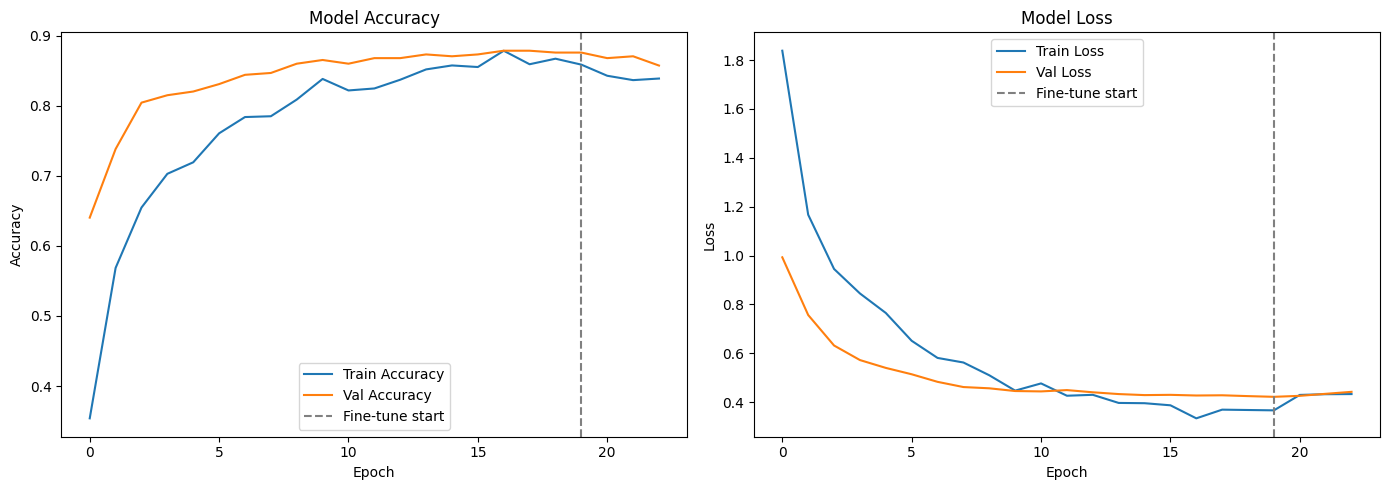

In [20]:
# Gabungkan history fase 1 dan fase 2
def combine_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

all_history = combine_history(history, fine_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(all_history['accuracy'], label='Train Accuracy')
axes[0].plot(all_history['val_accuracy'], label='Val Accuracy')
axes[0].axvline(x=len(history.history['accuracy'])-1,
               color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(all_history['loss'], label='Train Loss')
axes[1].plot(all_history['val_loss'], label='Val Loss')
axes[1].axvline(x=len(history.history['loss'])-1,
               color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


## **Evaluation**

In [21]:
# Reset generator sebelum predict — PENTING!
test_generator.reset()

pred_probs  = model.predict(test_generator, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = test_generator.classes

# Mapping index -> nama kelas
idx_to_class = {v: k for k, v in test_generator.class_indices.items()}
class_names  = [idx_to_class[i] for i in sorted(idx_to_class)]

print('Jumlah sampel test :', len(true_labels))
print('Jumlah prediksi    :', len(pred_labels))


12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 680ms/step
Jumlah sampel test : 383
Jumlah prediksi    : 383


In [22]:
print(classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
))


              precision    recall  f1-score   support

   cardboard       0.95      0.90      0.92        61
       glass       0.92      0.79      0.85        76
       metal       0.84      0.90      0.87        62
       paper       0.91      0.88      0.89        90
     plastic       0.81      0.93      0.87        73
       trash       0.77      0.81      0.79        21

    accuracy                           0.87       383
   macro avg       0.87      0.87      0.87       383
weighted avg       0.88      0.87      0.87       383



In [23]:
acc       = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, average='weighted')
recall    = recall_score(true_labels, pred_labels, average='weighted')
f1        = f1_score(true_labels, pred_labels, average='weighted')

print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')


Accuracy  : 0.8747
Precision : 0.8795
Recall    : 0.8747
F1-Score  : 0.8749


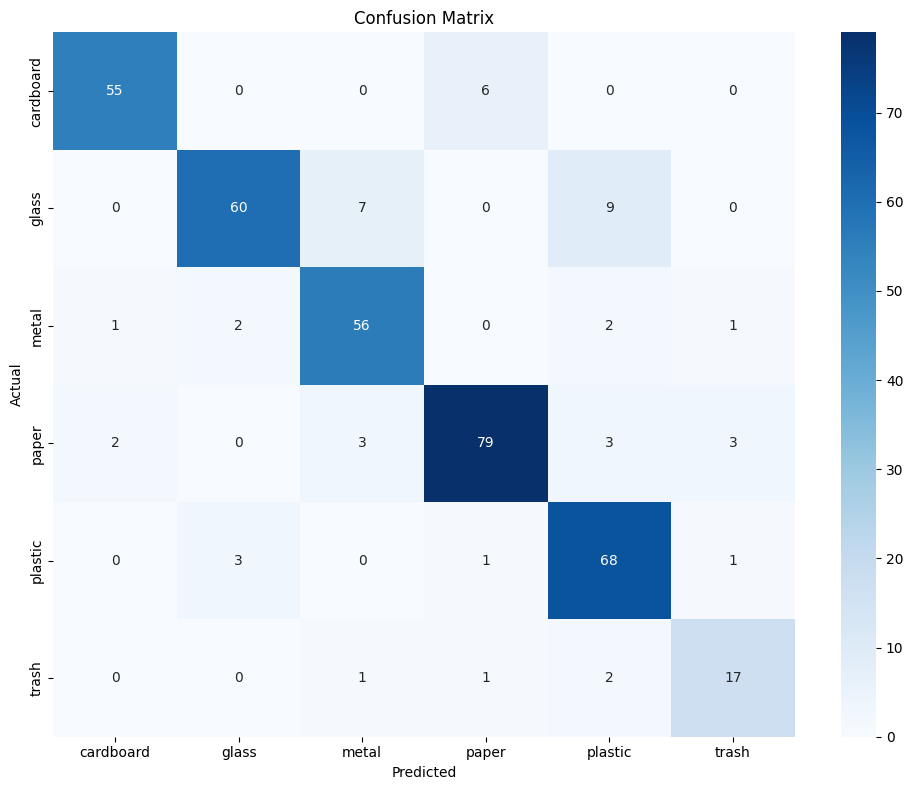

In [24]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [25]:
# Jalankan cell ini setelah generator dibuat
print("Generator class indices:", train_generator.class_indices)
print("Class weight dict:", class_weight_dict)

# Verifikasi: index 0 harus = kelas yang sama di keduanya

Generator class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Class weight dict: {0: np.float64(1.0437352245862883), 1: np.float64(0.840952380952381), 2: np.float64(1.0255516840882695), 3: np.float64(0.7092369477911646), 4: np.float64(0.8733926805143423), 5: np.float64(3.0982456140350876)}


In [26]:
# Pastikan folder train ada isinya
for cls in classes:
    path = os.path.join(TRAIN_DIR, cls)
    print(cls, len(os.listdir(path)), "files")

cardboard 282 files
glass 350 files
metal 287 files
paper 415 files
plastic 337 files
trash 95 files


In [27]:
# Harus dijalankan SETELAH train_generator dibuat
train_labels = train_generator.classes

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(weights))

# Verifikasi
print("Class indices dari generator:", train_generator.class_indices)
print("Class weight dict:", class_weight_dict)
# Pastikan key 0,1,2,... sesuai urutan class_indices di atas

Class indices dari generator: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Class weight dict: {0: np.float64(1.0437352245862883), 1: np.float64(0.840952380952381), 2: np.float64(1.0255516840882695), 3: np.float64(0.7092369477911646), 4: np.float64(0.8733926805143423), 5: np.float64(3.0982456140350876)}


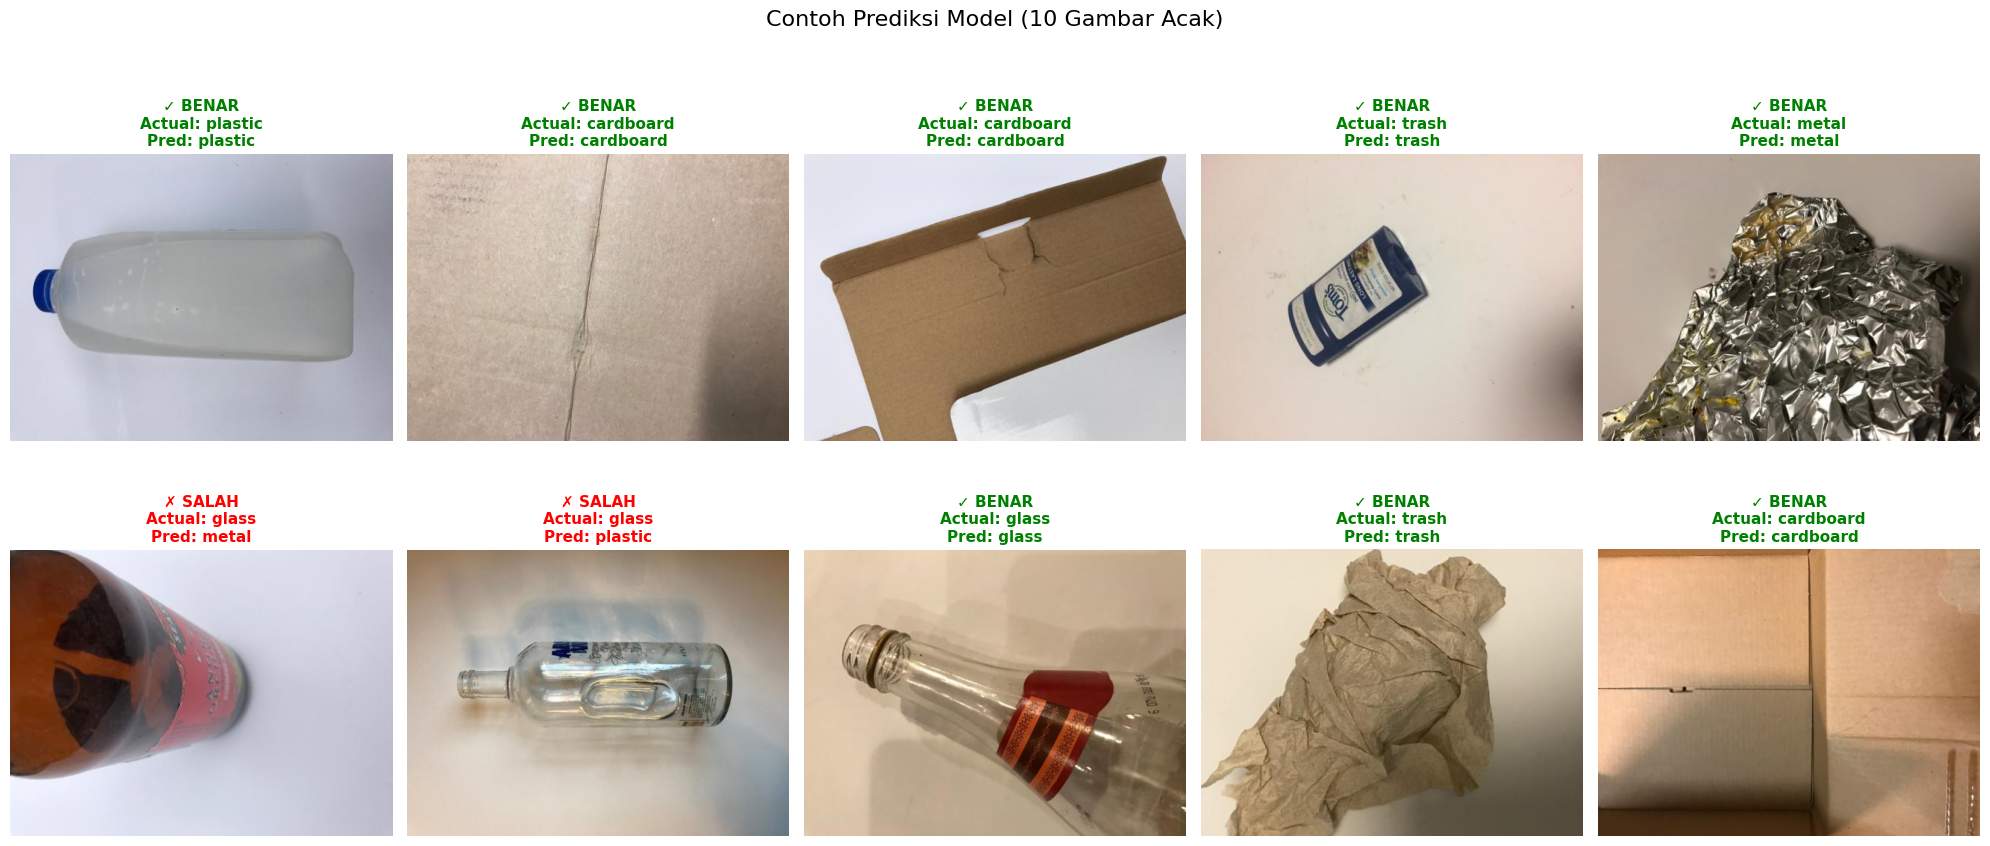

In [29]:
# Ambil path file dari test_generator (urutan sama dgn true_labels/pred_labels karena shuffle=False)
test_filepaths = test_generator.filepaths

# Pilih 10 index acak dari test set
random.seed(RANDOM_SEED)
sample_indices = random.sample(range(len(test_filepaths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img_path = test_filepaths[idx]
    img = Image.open(img_path)

    true_label = class_names[true_labels[idx]]
    pred_label = class_names[pred_labels[idx]]
    is_correct = true_label == pred_label

    axes[i].imshow(img)
    axes[i].axis('off')

    color = 'green' if is_correct else 'red'
    status = '✓ BENAR' if is_correct else '✗ SALAH'

    axes[i].set_title(
        f"{status}\nActual: {true_label}\nPred: {pred_label}",
        color=color,
        fontsize=11,
        fontweight='bold'
    )

plt.suptitle('Contoh Prediksi Model (10 Gambar Acak)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
